In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

In [2]:
df_bio_main = pd.read_csv('working_datasets/cleaned_biometrics_data.csv')
df_demo_main = pd.read_csv('working_datasets/cleaned_demographics_data.csv')
df_enrol_main = pd.read_csv('working_datasets/cleaned_enrolment_data.csv')

In [3]:
#defining features for enrollment, biometrics and demographics datasets to start isolation forest
enrol_features = df_enrol_main[['state', 'district','pincode','age_0_5','age_5_17','age_18_greater']]
bio_features = df_bio_main[['state', 'district','bio_age_5_17','bio_age_17_']]
demo_features = df_demo_main[['state', 'district','demo_age_5_17','demo_age_17_']]

In [5]:
#h(x) path length pof instance x
#E[h(x)] average path length across all isolation trees


In [6]:
#define the training parameters 
n_estimators = 100
contamination = 0.01
sample_size = 256

In [7]:
# One-hot encode categorical columns
enrol_features_encoded = pd.get_dummies(enrol_features, drop_first=True)

# Train Isolation Forest
isof_enrol = IsolationForest(
    n_estimators=n_estimators,
    contamination=contamination,
    max_samples=sample_size,
    random_state=42
)

isof_enrol.fit(enrol_features_encoded)

# Add anomaly scores back to original dataframe
enrol_features['anomaly_score'] = isof_enrol.decision_function(enrol_features_encoded)
enrol_features['anomaly'] = isof_enrol.predict(enrol_features_encoded)

anomalies_enrol = enrol_features[enrol_features['anomaly'] == -1]

print(f'Number of anomalies detected in enrollment data: {len(anomalies_enrol)}')

C:\Users\Aaryan\AppData\Local\Temp\ipykernel_23072\2062997701.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enrol_features['anomaly_score'] = isof_enrol.decision_function(enrol_features_encoded)


Number of anomalies detected in enrollment data: 9816


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(enrol_features_encoded)

isof_enrol.fit(X_scaled)

enrol_features['anomaly_score'] = isof_enrol.decision_function(X_scaled)
enrol_features['anomaly'] = isof_enrol.predict(X_scaled)

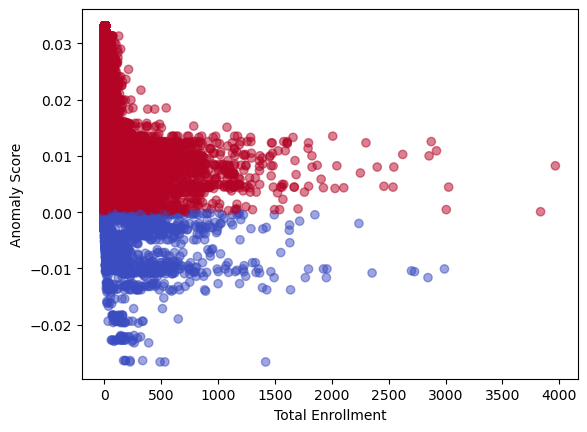

In [9]:
enrol_features['total_enrollment'] = df_enrol_main[['age_0_5', 'age_5_17', 'age_18_greater']].sum(axis=1)

plt.scatter(
    enrol_features['total_enrollment'],
    enrol_features['anomaly_score'],
    c=enrol_features['anomaly'],
    cmap='coolwarm',
    alpha=0.5
)
plt.xlabel("Total Enrollment")
plt.ylabel("Anomaly Score")
plt.savefig('anomaly_graphs/enrolment_anomaly_data_1.png')
plt.show()


In [10]:
# repeating the above process for btoth bio as well as demo data

In [11]:
# One-hot encode categorical columns
bio_features_encoded = pd.get_dummies(bio_features, drop_first=True)

# Train Isolation Forest
isof_bio = IsolationForest(
    n_estimators=n_estimators,
    contamination=contamination,
    max_samples=sample_size,
    random_state=42
)

isof_bio.fit(bio_features_encoded)

# Add anomaly scores back to original dataframe
bio_features['anomaly_score'] = isof_bio.decision_function(bio_features_encoded)
bio_features['anomaly'] = isof_bio.predict(bio_features_encoded)

anomalies_bio = bio_features[bio_features['anomaly'] == -1]

print(f'Number of anomalies detected in biolment data: {len(anomalies_bio)}')

C:\Users\Aaryan\AppData\Local\Temp\ipykernel_23072\1648272772.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bio_features['anomaly_score'] = isof_bio.decision_function(bio_features_encoded)


Number of anomalies detected in biolment data: 17606


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bio_features_encoded)

isof_bio.fit(X_scaled)

bio_features['anomaly_score'] = isof_bio.decision_function(X_scaled)
bio_features['anomaly'] = isof_bio.predict(X_scaled)

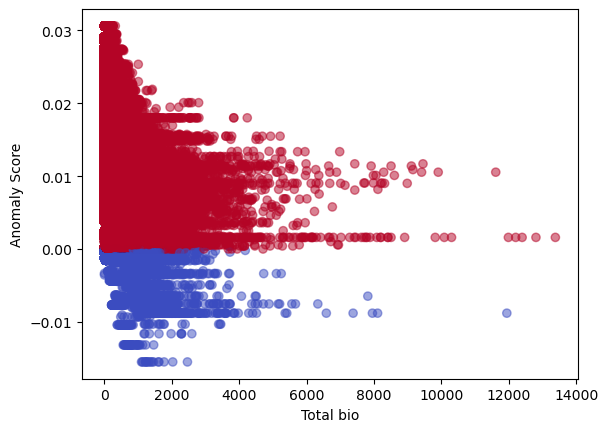

In [14]:
bio_features['total_bioment'] = df_bio_main[['bio_age_5_17','bio_age_17_']].sum(axis=1)

plt.scatter(
    bio_features['total_bioment'],
    bio_features['anomaly_score'],
    c=bio_features['anomaly'],
    cmap='coolwarm',
    alpha=0.5
)
plt.xlabel("Total bio")
plt.ylabel("Anomaly Score")
plt.savefig('anomaly_graphs/biometrics_anomaly_data.png')
plt.show()


In [15]:
# One-hot encode categorical columns
demo_features_encoded = pd.get_dummies(demo_features, drop_first=True)

# Train Isolation Forest
isof_demo = IsolationForest(
    n_estimators=n_estimators,
    contamination=contamination,
    max_samples=sample_size,
    random_state=42
)

isof_demo.fit(demo_features_encoded)

# Add anomaly scores back to original dataframe
demo_features['anomaly_score'] = isof_demo.decision_function(demo_features_encoded)
demo_features['anomaly'] = isof_demo.predict(demo_features_encoded)

anomalies_demo = demo_features[demo_features['anomaly'] == -1]

print(f'Number of anomalies detected in demolment data: {len(anomalies_demo)}')

C:\Users\Aaryan\AppData\Local\Temp\ipykernel_23072\2723666244.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_features['anomaly_score'] = isof_demo.decision_function(demo_features_encoded)


Number of anomalies detected in demolment data: 15729


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(demo_features_encoded)

isof_demo.fit(X_scaled)

demo_features['anomaly_score'] = isof_demo.decision_function(X_scaled)
demo_features['anomaly'] = isof_demo.predict(X_scaled)

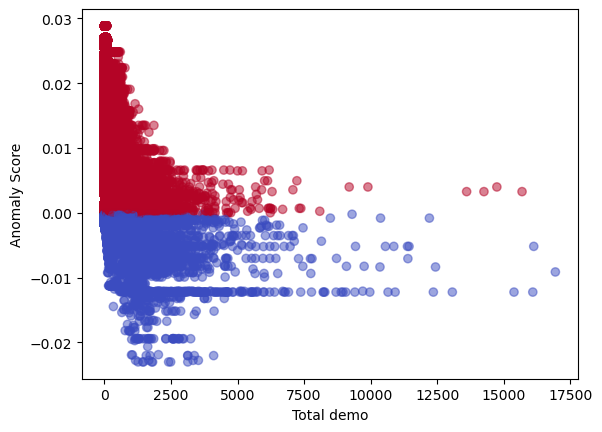

In [17]:
demo_features['total_demoment'] = df_demo_main[['demo_age_5_17','demo_age_17_']].sum(axis=1)

plt.scatter(
    demo_features['total_demoment'],
    demo_features['anomaly_score'],
    c=demo_features['anomaly'],
    cmap='coolwarm',
    alpha=0.5
)
plt.xlabel("Total demo")
plt.ylabel("Anomaly Score")
plt.savefig('anomaly_graphs/demographics_anomaly_data.png')
plt.show()
